## PART I:  fitting the signal, bakground

In [261]:
import sys,os
import numpy as np
import scipy
from scipy.integrate import quad
from scipy.stats import kde
from scipy.stats import chi2 as spchi2
from scipy.optimize import minimize,leastsq
import matplotlib
import matplotlib.pyplot as py
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=True)  
%matplotlib inline  
%config InlineBackend.figure_format = 'retina'
from tools import tex,save, load,fill_between,plot_hist
from tools import EVENTS,VEC4

## The background

Retrieve simulated background and construct lepton-pair invariant mass

In [262]:
path='samples/bkg.lhe.gz'
bkg=EVENTS(path)
bkg.D['m']=[]
for i in range(bkg.nevents):
    particles=bkg.EVENTS[i]
    for p in particles:
        if p['pid']==-13: mub=p['mom']
        elif p['pid']==13: mu=p['mom']
    z=mu+mub
    bkg.D['m'].append((z*z)**0.5) 

construct observable as $\frac{1}{N_{tot}}~~\frac{dN}{dm}$

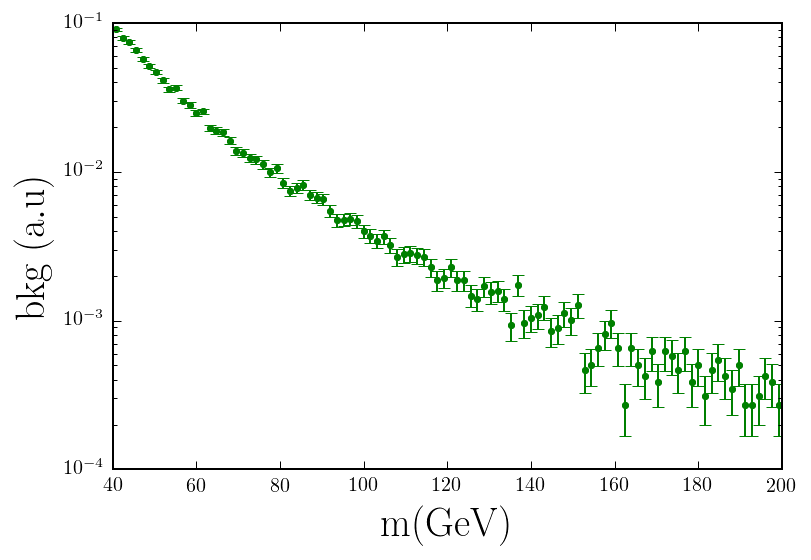

In [263]:
N,E=np.histogram(bkg.D['m'],bins=100,range=(40,200))

M=0.5*(E[:-1]+E[1:])
NTOT=np.sum(N)
OBS=N/float(NTOT)
ERR=N/float(NTOT)*(np.sqrt(N)/N+np.sqrt(NTOT)/float(NTOT))

ax=py.subplot(111)
ax.errorbar(M,OBS,yerr=ERR,fmt='g.')
ax.set_ylabel(tex(r'bkg~(a.u)'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)
ax.semilogy();

model the bkg and make fit

In [265]:
rs=1300.0
model_bkg1 = lambda p,m: p[0]/m**(p[1])*(1+p[2]*(m/rs))
res=lambda p: (OBS-model_bkg1(p,M))/ERR
params_input = [1,1.5,1]
fit=leastsq(res,params_input)
popt1=fit[0]
res0=res(popt1)
chi21bkg=np.dot(res0,res0)
chi2dof=chi21bkg/(OBS.size-popt1.size)
print 'model 1 for bkg'
print popt1
print ['chi^2=',chi21bkg]
print ['chi^2/dof=',chi2dof]

model 1 for bkg
[  1.71463588e+04   3.23083374e+00  -4.04992077e+00]
['chi^2=', 92.805726766833544]
['chi^2/dof=', 0.95676006976117056]


check the results

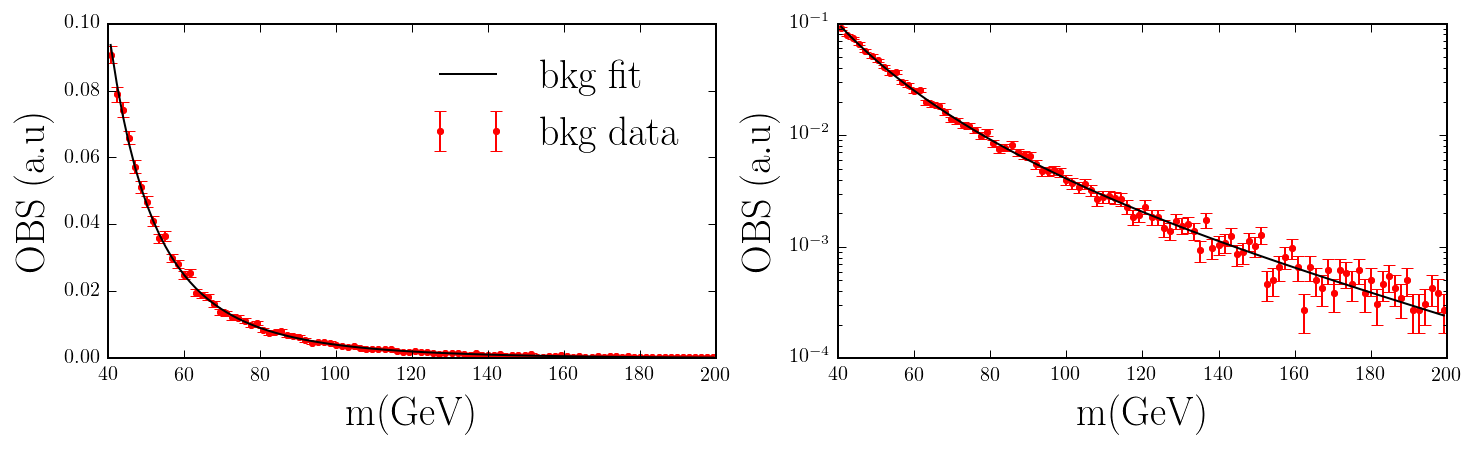

In [266]:
py.figure(figsize=(2*6,1*3))
ax=py.subplot(121)
ax.errorbar(M,OBS,yerr=ERR,fmt='r.',label=tex('bkg~data'))
ax.plot(M,model_bkg1(popt1,M),'k-',label=tex('bkg~fit'))
ax.set_ylabel(tex(r'OBS~(a.u)'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)
ax.legend(fontsize=20,frameon=0)

ax=py.subplot(122)
ax.errorbar(M,OBS,yerr=ERR,fmt='r.')
ax.plot(M,model_bkg1(popt1,M),'k-')
ax.set_ylabel(tex(r'OBS~(a.u)'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)
ax.semilogy();

# The signal

Retrieve simulated signal and construct lepton-pair invariant mass

In [267]:
path='samples/sig.lhe.gz'
sig=EVENTS(path)
sig.D['m']=[]
for i in range(sig.nevents):
    particles=sig.EVENTS[i]
    for p in particles:
        if p['pid']==-13: mub=p['mom']
        elif p['pid']==13: mu=p['mom']
    z=mu+mub
    sig.D['m'].append((z*z)**0.5) 

construct observable as $\frac{1}{N_{tot}}~~\frac{dN}{dm}$

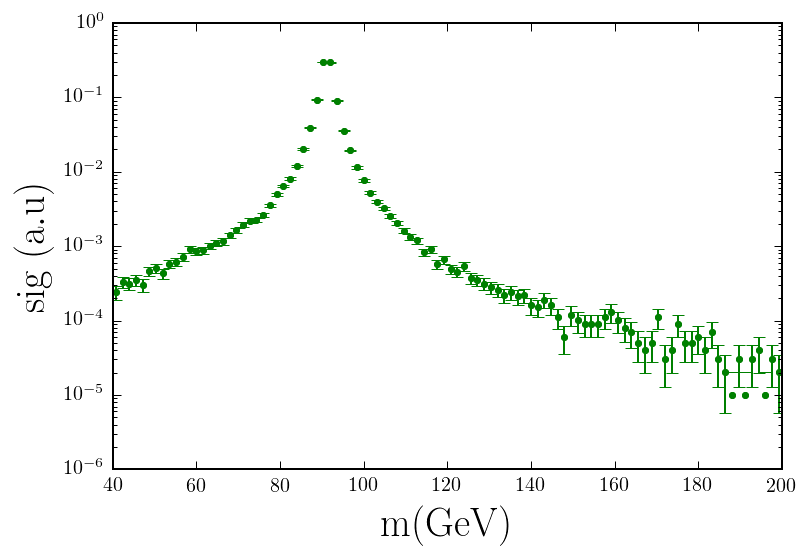

In [268]:
N,E=np.histogram(sig.D['m'],bins=100,range=(40,200))

M=0.5*(E[:-1]+E[1:])
NTOT=np.sum(N)
OBS=N/float(NTOT)
ERR=N/float(NTOT)*(np.sqrt(N)/N+np.sqrt(NTOT)/float(NTOT))

ax=py.subplot(111)
#plot_hist(ax,'r',E,OBS)
ax.errorbar(M,OBS,yerr=ERR,fmt='g.')
ax.set_ylabel(tex(r'sig~(a.u)'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)
ax.semilogy();

model the signal and make fit

In [272]:
rs=1300.0
model_sig1 = lambda p,m: p[0]*m**2 /((m**2-p[1]**2)**2+m**2 *p[2]**2) *(1+p[3]*(m/rs) + p[4]*(m/rs)**2)
res=lambda p: (OBS-model_sig1(p,M))/ERR
params_input = np.zeros(5)+1
fit=leastsq(res,params_input)
popt1=fit[0]
res0=res(popt1)
chi21sig = np.dot(res0,res0)
chi2dof=chi21sig/(OBS.size-popt1.size)
print ['parameters=', popt1 ]
print ['chi^2=', chi21sig]
print ['chi^2/dof=', chi2dof]

['parameters=', array([  9.17477589,  91.20641688,  -2.51228383, -13.6328917 ,  49.66012099])]
['chi^2=', 120.66033051760799]
['chi^2/dof=', 1.2701087422906103]


check the results

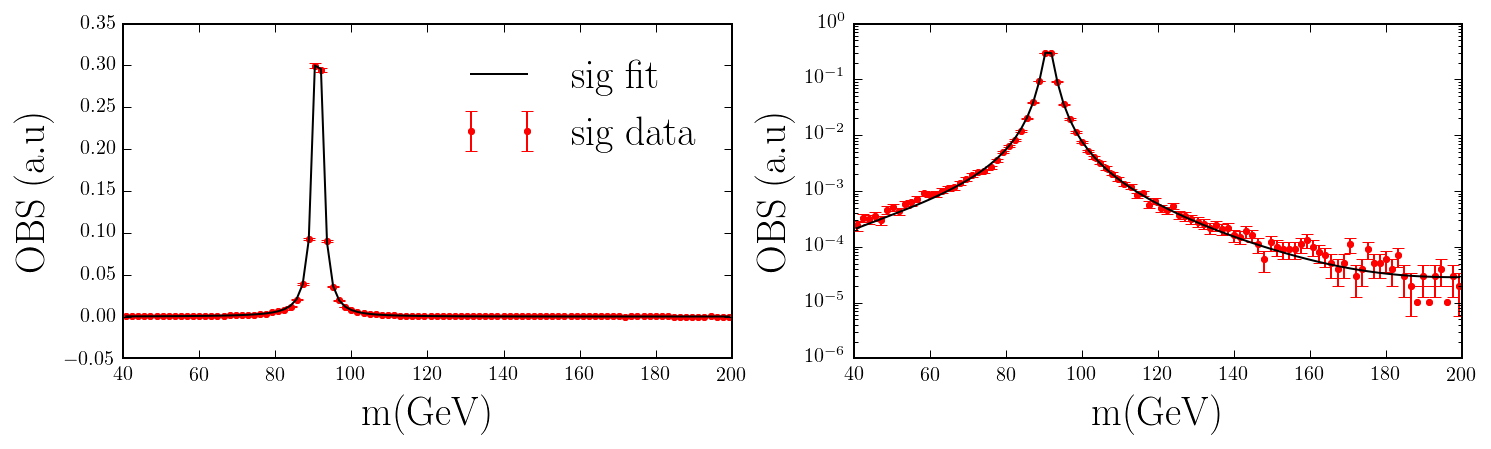

In [273]:
py.figure(figsize=(2*6,1*3))
ax=py.subplot(121)
ax.errorbar(M,OBS,yerr=ERR,fmt='r.',label=tex('sig~data'))
ax.plot(M,model_sig1(popt1,M),'k-',label=tex('sig~fit'))
ax.set_ylabel(tex(r'OBS~(a.u)'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)
ax.legend(fontsize=20,frameon=0)

ax=py.subplot(122)
ax.errorbar(M,OBS,yerr=ERR,fmt='r.')
ax.plot(M,model_sig1(popt1,M),'k-')
ax.set_ylabel(tex(r'OBS~(a.u)'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)
ax.semilogy();

# The signal + background

Retrieve simulated + background signal and construct lepton-pair invariant mass

In [274]:
path='samples/sb.lhe.gz'
sb=EVENTS(path)
sb.D['m']=[]
for i in range(sb.nevents):
    particles=sb.EVENTS[i]
    for p in particles:
        if p['pid']==-13: mub=p['mom']
        elif p['pid']==13: mu=p['mom']
    z=mu+mub
    sb.D['m'].append((z*z)**0.5) 

construct observable as $\frac{1}{N_{tot}}~~\frac{dN}{dm}$

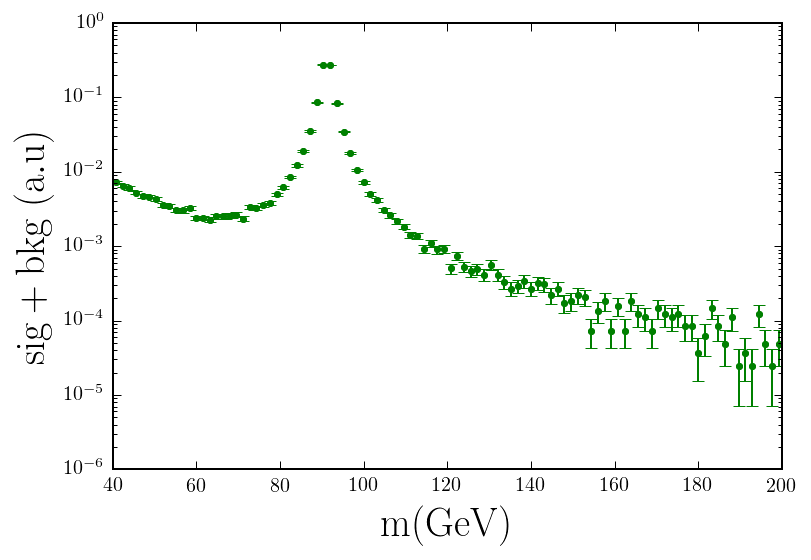

In [275]:
N,E=np.histogram(sb.D['m'],bins=100,range=(40,200))

M=0.5*(E[:-1]+E[1:])
NTOT=np.sum(N)
OBS=N/float(NTOT)
ERR=N/float(NTOT)*(np.sqrt(N)/N+np.sqrt(NTOT)/float(NTOT))

ax=py.subplot(111)
ax.errorbar(M,OBS,yerr=ERR,fmt='g.')
ax.set_ylabel(tex(r'sig+bkg~(a.u)'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)
ax.semilogy();

model the signal+background and make fit

In [276]:
rs=1300.0
model_sig = lambda p,m: p[0]*m**2 /((m**2-p[1]**2)**2+m**2 *p[2]**2)*(1+p[3]*(m/rs) + p[4]*(m/rs)**2)
model_bkg = lambda p,m: p[5]/m**(p[6])*(1+p[7]*(m/rs))
res=lambda p: (OBS-model_sb(p,M))/ERR
params_input = [1,91,1,1,1,1,1,1]
fit=leastsq(res,params_input,full_output=1)
popt=fit[0]
res0=res(popt)
chi2sb  = np.dot(res0,res0)
chi2dof = chi2sb/(OBS.size-popt.size)
print ['parameters=', popt]
print ['chi^2=', chi2sb]
print ['chi^2/dof=', chi2dof]

['parameters=', array([    7.39761555,    91.20751411,     2.48863374,   -12.37830847,
          39.32303252,  1378.03079814,     3.26161113,    -1.49041019])]
['chi^2=', 111.26196955663274]
['chi^2/dof=', 1.2093692343112254]


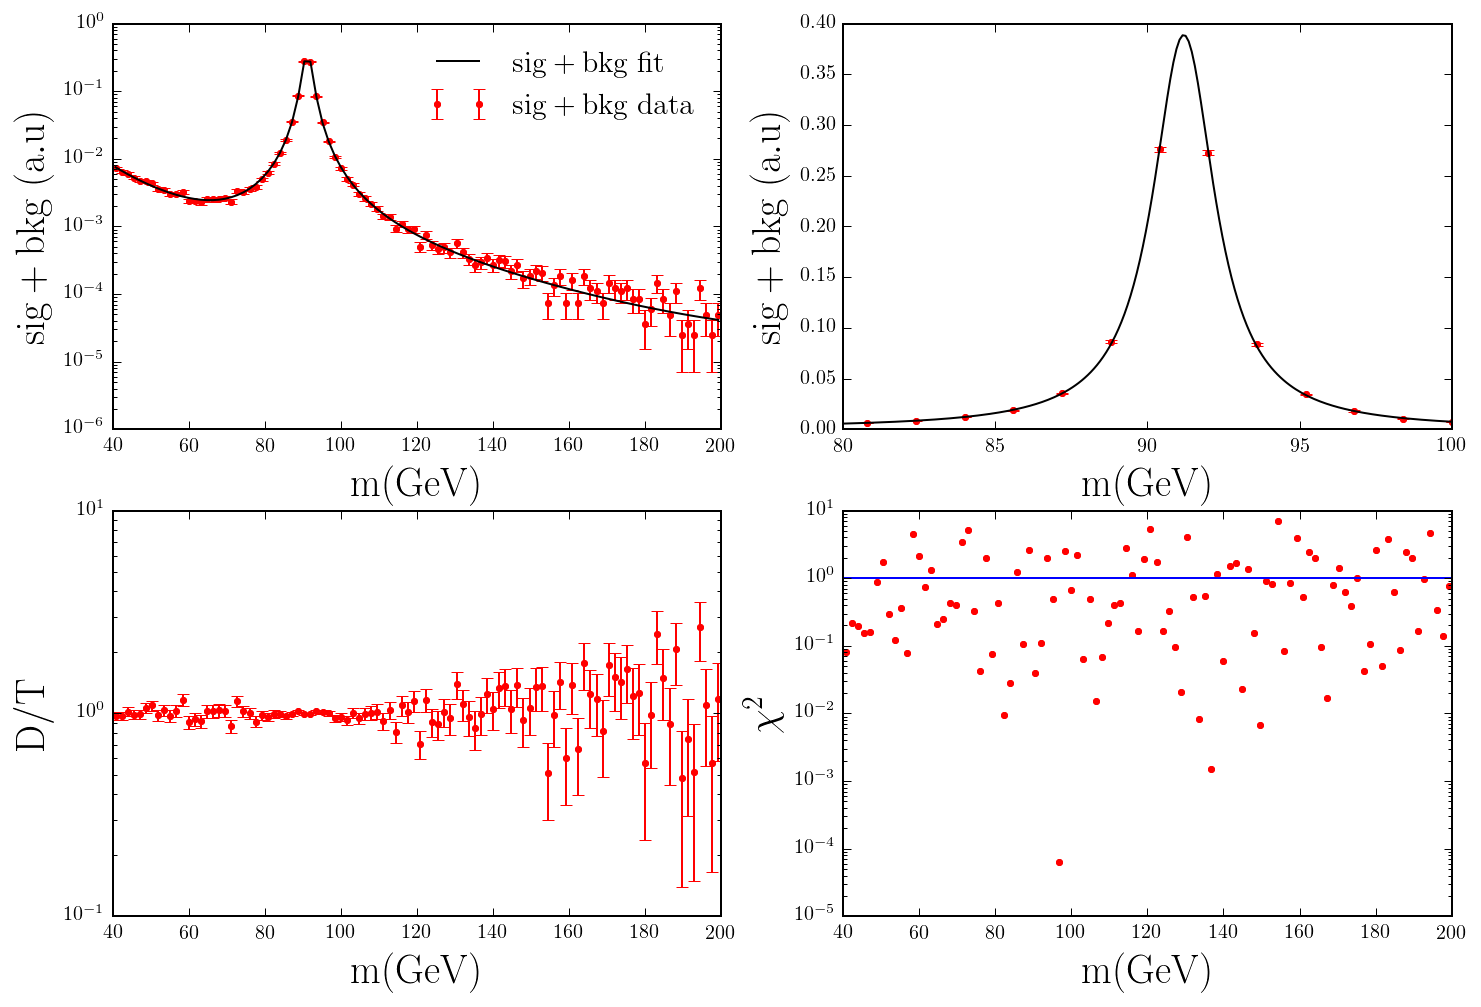

In [277]:
py.figure(figsize=(2*6,2*4))
ax=py.subplot(221)
ax.errorbar(M,OBS,yerr=ERR,fmt='r.',label=tex('sig+bkg~data'))
ax.plot(M,model_sb(popt,M),'k-',label=tex('sig+bkg~fit'))
ax.set_ylabel(tex(r'sig+bkg~(a.u)'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)
ax.semilogy();
ax.legend(fontsize=15,frameon=0)

ax=py.subplot(222)
ax.errorbar(M,OBS,yerr=ERR,fmt='r.',label=tex('sig+bkg~data'))
M0=np.linspace(80,100,200)
ax.plot(M0,model_sb(popt,M0),'k-',label=tex('sig+bkg~fit'))
ax.set_xlim(np.amin(M0),np.amax(M0))
ax.set_ylabel(tex(r'sig+bkg~(a.u)'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)

ax=py.subplot(223)
ax.errorbar(M,OBS/model_sb(popt,M),yerr=ERR/model_sb(popt,M),fmt='r.',label=tex('sig+bkg~data'))
ax.set_ylabel(tex(r'D/T'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)
ax.semilogy();

ax=py.subplot(224)
ax.plot(M,CHI2,'r.')
ax.set_ylabel(tex(r'\chi^2'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)
ax.axhline(1)
ax.semilogy();

# Correlation plot

<matplotlib.colorbar.Colorbar instance at 0x132991878>

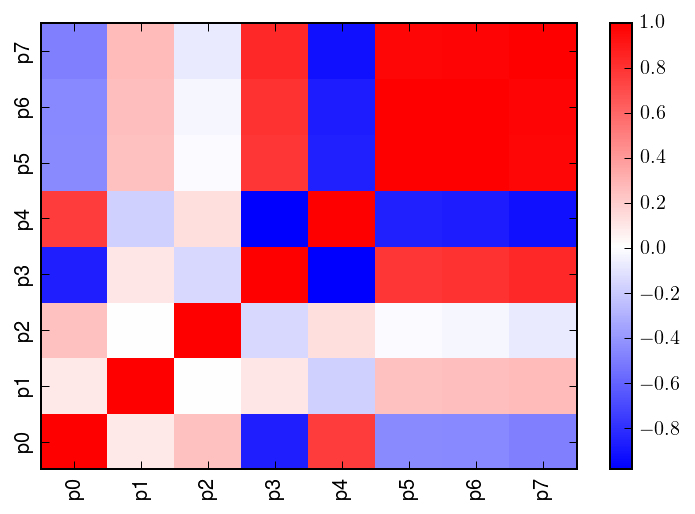

In [278]:
popt, pcov, infodict, errmsg, ier = fit
fjac=infodict['fjac']
npts=OBS.size
s_sq = (infodict['fvec']**2).sum()/npts
cov = pcov * s_sq
cor=np.zeros(cov.shape)

I=len(cov)
for i in range(I):
    for j in range(I):
        cor[i,j]=cov[i,j]/np.sqrt(cov[i,i]*cov[j,j])

ax=py.subplot(111)
pc=ax.pcolor(cor,cmap='bwr')

ax.set_xticks(np.arange(len(cor))+0.5)
ax.set_xticklabels(['p%d'%i for i in range(len(cor))],rotation=90)
ax.set_yticks(np.arange(len(cor))+0.5)
ax.set_yticklabels(['p%d'%i for i in range(len(cor))],rotation=90)
ax.set_xlim(0,len(cor))
ax.set_ylim(0,len(cor))

py.colorbar(pc)
